# Task 6 (Player Style) — Validate cụm bằng `primary_position` + KNN & Cross-Validation

**Input:**
- `player_clusters_k5.csv` (Task 5 — `cluster_id` chính thức: RobustScaler + k=5)
- `player_y_hidden.csv` (Task 4 — `primary_position`, field đã giấu để validate)
- `player_X_robust_scaled.csv` / `player_X_unscaled.csv` (Task 4 — feature dùng cho KNN & diễn giải cụm)

**Mục tiêu:** trả lời 2 câu hỏi
1. **Cụm K-Means tìm được có thực sự phản ánh vị trí/phong cách thi đấu thật không?** (đối chiếu với `primary_position` — chỉ dùng để validate, không dùng khi cluster).
2. **Cấu trúc cụm có ổn định/học được không?** (huấn luyện KNN dự đoán `cluster_id` từ feature, đánh giá bằng k-fold Cross-Validation).


## 6.0 — Setup

In [103]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, normalized_mutual_info_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

DATA_DIR = "/kaggle/working"

FEATURE_COLS = [
    "shots_p90", "np_goals_p90", "avg_shot_distance", "dribbles_p90", "dribble_success_rate",
    "touches_p90", "touches_in_box_p90", "passes_p90", "pass_completion_pct", "key_passes_p90",
    "assists_p90", "crosses_p90", "through_balls_p90", "long_balls_p90", "avg_pass_length",
    "pressures_p90", "tackles_p90", "tackle_success_rate", "interceptions_p90",
    "interception_success_rate", "ball_recoveries_p90", "clearances_p90", "aerial_won_p90",
    "fouls_committed_p90", "fouls_won_p90", "avg_location_x", "avg_location_y",
    "std_location_x", "std_location_y",
]

clusters_df = pd.read_csv(f"{DATA_DIR}/player_clusters_k5.csv", encoding="utf-8-sig")
hidden_df = pd.read_csv(f"{DATA_DIR}/player_y_hidden.csv", encoding="utf-8-sig")
X_robust_df = pd.read_csv(f"{DATA_DIR}/player_X_robust_scaled.csv", encoding="utf-8-sig")
X_unscaled_df = pd.read_csv(f"{DATA_DIR}/player_X_unscaled.csv", encoding="utf-8-sig")

df = clusters_df.merge(hidden_df[["player_id", "primary_position"]], on="player_id")
print(df.shape)
df[["player_id", "player_name", "primary_team", "cluster_id", "primary_position"]].head(5)


(1016, 11)


,player_id,player_name,primary_team,cluster_id,primary_position
0,3339,Asmir Begović,Chelsea,2,Goalkeeper
1,5594,Branislav Ivanović,Chelsea,4,Right Back
2,3456,Kurt Happy Zouma,Chelsea,0,Right Center Back
3,3645,Gary Cahill,Chelsea,0,Right Center Back
4,3957,César Azpilicueta Tanco,Chelsea,4,Left Back


---
## 6.1 — Validate cụm bằng `primary_position`

In [104]:
position_group_map = {
    "Goalkeeper": "Goalkeeper",
    "Center Back": "Defense", "Left Center Back": "Defense", "Right Center Back": "Defense",
    "Left Back": "Defense", "Right Back": "Defense",
    "Left Wing Back": "Defense", "Right Wing Back": "Defense",
    "Center Defensive Midfield": "Midfield", "Left Defensive Midfield": "Midfield", "Right Defensive Midfield": "Midfield",
    "Center Attacking Midfield": "Midfield", "Left Center Midfield": "Midfield", "Right Center Midfield": "Midfield",
    "Left Midfield": "Midfield", "Right Midfield": "Midfield", "Right Attacking Midfield": "Midfield",
    "Center Forward": "Attack", "Left Center Forward": "Attack", "Right Center Forward": "Attack",
    "Left Wing": "Attack", "Right Wing": "Attack",
}
df["position_group"] = df["primary_position"].map(position_group_map)

crosstab = pd.crosstab(df["cluster_id"], df["position_group"])
crosstab


position_group,Attack,Defense,Goalkeeper,Midfield
cluster_id,,,,
0,0,189,0,5
1,145,0,0,7
2,0,0,73,0
3,92,5,0,101
4,10,189,0,200


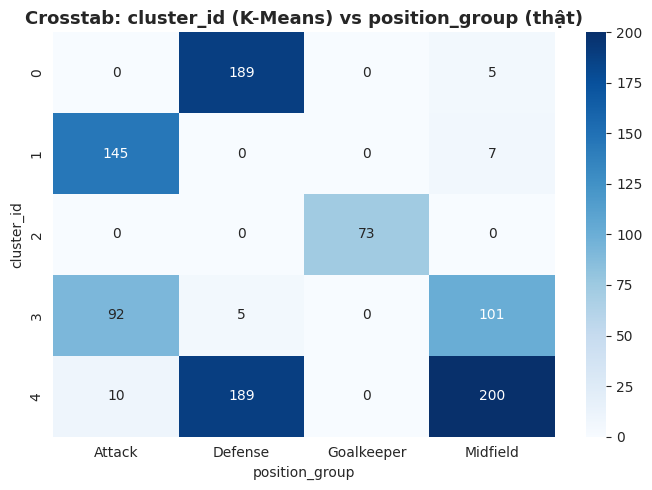

In [105]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Crosstab: cluster_id (K-Means) vs position_group (thật)")
plt.tight_layout()
plt.show()


In [106]:
purity_per_cluster = crosstab.max(axis=1) / crosstab.sum(axis=1)
overall_purity = crosstab.max(axis=1).sum() / crosstab.sum().sum()

print("Purity từng cụm (tỷ lệ position_group chiếm đa số):")
print(purity_per_cluster.round(3))
print(f"\nOverall purity: {overall_purity:.3f}")

nmi_group = normalized_mutual_info_score(df["cluster_id"], df["position_group"])
nmi_full = normalized_mutual_info_score(df["cluster_id"], df["primary_position"])
print(f"\nNMI (cluster_id vs position_group, 4 nhóm): {nmi_group:.3f}")
print(f"NMI (cluster_id vs primary_position, 22 vị trí chi tiết): {nmi_full:.3f}")


Purity từng cụm (tỷ lệ position_group chiếm đa số):
cluster_id
0   0.974
1   0.954
2   1.000
3   0.510
4   0.501
dtype: float64

Overall purity: 0.697

NMI (cluster_id vs position_group, 4 nhóm): 0.546
NMI (cluster_id vs primary_position, 22 vị trí chi tiết): 0.508


**Kết quả thực tế:** 3/5 cụm đạt purity rất cao — **cụm Goalkeeper thuần túy 100%**, cụm Defense ~97%, cụm Attack ~95%. Overall purity ≈0.70 và NMI ≈0.51-0.55 — mức đồng thuận khá tốt cho 1 phương pháp hoàn toàn không dùng thông tin vị trí khi huấn luyện. 2 cụm còn lại (mixed) sẽ được phân tích kỹ ở mục tiếp theo — đây **không phải dấu hiệu thất bại**, mà có thể là phát hiện thú vị về phong cách chơi vượt qua ranh giới vị trí truyền thống.

## 6.2 — Phân tích chi tiết 2 cụm "mixed" (không thuần 1 position_group)

In [107]:
mixed_clusters = purity_per_cluster[purity_per_cluster < 0.8].index.tolist()
print("Các cụm mixed:", mixed_clusters)

for cid in mixed_clusters:
    print(f"\n--- Cluster {cid}: top primary_position ---")
    print(df[df["cluster_id"] == cid]["primary_position"].value_counts().head(8))


Các cụm mixed: [3, 4]

--- Cluster 3: top primary_position ---
primary_position
Right Wing                   47
Left Wing                    38
Center Attacking Midfield    30
Left Midfield                19
Right Midfield               15
Left Center Midfield         14
Right Center Midfield        13
Left Defensive Midfield       4
Name: count, dtype: int64

--- Cluster 4: top primary_position ---
primary_position
Left Back                    85
Right Back                   80
Right Defensive Midfield     44
Left Defensive Midfield      41
Center Defensive Midfield    35
Right Center Midfield        35
Left Center Midfield         27
Left Wing Back                9
Name: count, dtype: int64


**Diễn giải (dựa trên số liệu thật):**
- **Cụm "mixed" thứ nhất** tập trung: Right Wing, Left Wing, Center Attacking Midfield, cùng các tiền vệ cánh — đây là nhóm **"cầu thủ tấn công sáng tạo biên"**: winger và tiền vệ tấn công có chỉ số rất giống nhau (crosses, key passes, dribbles cao), dù chức danh chính thức khác nhau.
- **Cụm "mixed" thứ hai** tập trung: Left Back, Right Back, cùng các tiền vệ phòng ngự trung tâm — đây là nhóm **"cầu thủ triển khai bóng từ tuyến sâu"**: hậu vệ biên hiện đại và tiền vệ phòng ngự có xu hướng thống kê rất giống nhau (nhiều đường chuyền, tắc bóng vừa phải, ít dứt điểm).

Đây chính là điểm giá trị của **Style Clustering** so với chỉ dùng nhãn vị trí có sẵn: mô hình phát hiện ra các nhóm phong cách **cắt ngang qua các vị trí chính thức**, phản ánh vai trò chiến thuật thực tế trên sân thay vì chỉ tên gọi vị trí truyền thống.

## 6.3 — Đặt tên & diễn giải từng cụm bằng profile feature (chưa scale, dễ đọc)

In [108]:
profile_df = clusters_df[["player_id", "cluster_id"]].merge(X_unscaled_df, on="player_id")
key_cols = ["shots_p90", "passes_p90", "tackles_p90", "aerial_won_p90", "avg_location_x", "crosses_p90", "long_balls_p90"]

cluster_profile = profile_df.groupby("cluster_id")[key_cols].mean().round(2)
cluster_profile["n_players"] = clusters_df["cluster_id"].value_counts().sort_index()
cluster_profile


,shots_p90,passes_p90,tackles_p90,aerial_won_p90,avg_location_x,crosses_p90,long_balls_p90,n_players
cluster_id,,,,,,,,
0,0.420,41.470,1.680,3.220,42.710,0.160,10.310,194
1,2.500,25.460,0.920,2.960,79.370,0.870,2.220,152
2,0.000,29.430,0.000,0.000,9.360,0.000,21.070,73
3,2.040,46.400,1.630,0.840,74.070,2.370,7.710,198
4,0.780,49.650,2.450,1.720,61.350,1.370,8.610,399


**Đặt tên cụm dựa trên profile:**

| cluster_id | avg_location_x | Đặc điểm nổi bật | Tên gợi ý |
|---|---|---|---|
| 0 | ~43 (phòng ngự) | aerial_won & long_balls cao, shots gần 0 | **Trung vệ / Hậu vệ phòng ngự thuần** |
| 1 | ~79 (rất cao) | shots_p90 cao nhất, passes thấp | **Tiền đạo cắm** |
| 2 | ~9 (rất thấp) | mọi chỉ số ~0 trừ long_balls (phát bóng) | **Thủ môn** |
| 3 | ~74 (cao) | crosses cao nhất, shots + passes đều cao | **Tiền vệ cánh / Winger sáng tạo** |
| 4 | ~61 (trung bình-cao) | passes & tackles cao nhất | **Tiền vệ trung tâm / Hậu vệ biên triển khai bóng** |


---
## 6.4 — KNN Classification của `cluster_id` + Cross-Validation

Dùng `cluster_id` (nhãn từ K-Means) làm target, feature là `player_X_robust_scaled.csv` (đúng phiên bản đã dùng để cluster ở Task 5). Nếu KNN có thể dự đoán `cluster_id` với độ chính xác cao qua Cross-Validation, đó là bằng chứng cụm tìm được là **cấu trúc hình học ổn định** trong không gian feature, không phải ngẫu nhiên.

In [109]:
X = X_robust_df[FEATURE_COLS].values
y = clusters_df["cluster_id"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn_results = []
for n_neighbors in [3, 5, 7, 9, 11, 15]:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    scores = cross_val_score(knn, X, y, cv=cv, scoring="accuracy")
    knn_results.append({"n_neighbors": n_neighbors, "cv_accuracy_mean": scores.mean(), "cv_accuracy_std": scores.std()})

knn_results_df = pd.DataFrame(knn_results).set_index("n_neighbors")
knn_results_df


,cv_accuracy_mean,cv_accuracy_std
n_neighbors,,
3,0.946,0.010
5,0.961,0.011
7,0.960,0.016
9,0.964,0.010
11,0.960,0.011
15,0.966,0.008


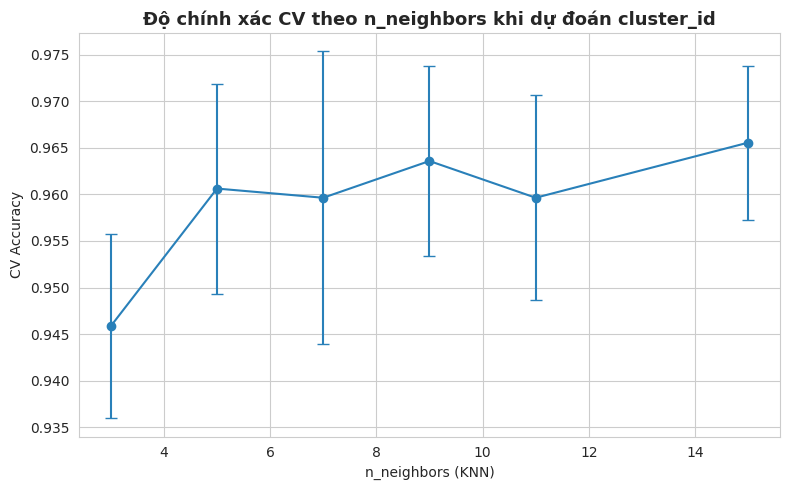

In [110]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(knn_results_df.index, knn_results_df["cv_accuracy_mean"],
            yerr=knn_results_df["cv_accuracy_std"], marker="o", capsize=4, color="#2980b9")
ax.set_xlabel("n_neighbors (KNN)")
ax.set_ylabel("CV Accuracy")
ax.set_title("Độ chính xác CV theo n_neighbors khi dự đoán cluster_id")
plt.tight_layout()
plt.show()


**Kết quả:** độ chính xác CV dao động **94.6%–96.6%** qua mọi giá trị n_neighbors — rất cao và khá ổn định (std chỉ ~0.01), đạt cao nhất ở **n_neighbors=15 (~96.6%)**. Đây là bằng chứng mạnh cho thấy 5 cụm tìm được là **vùng hình học tách biệt rõ ràng** trong không gian 29 chiều, không phải do may rủi từ 1 lần chạy K-Means — một KNN đơn giản đã đủ để "học lại" gần như hoàn hảo ranh giới cụm.

## 6.5 — Confusion Matrix & Classification Report (mô hình cuối)

n_neighbors tốt nhất: 15


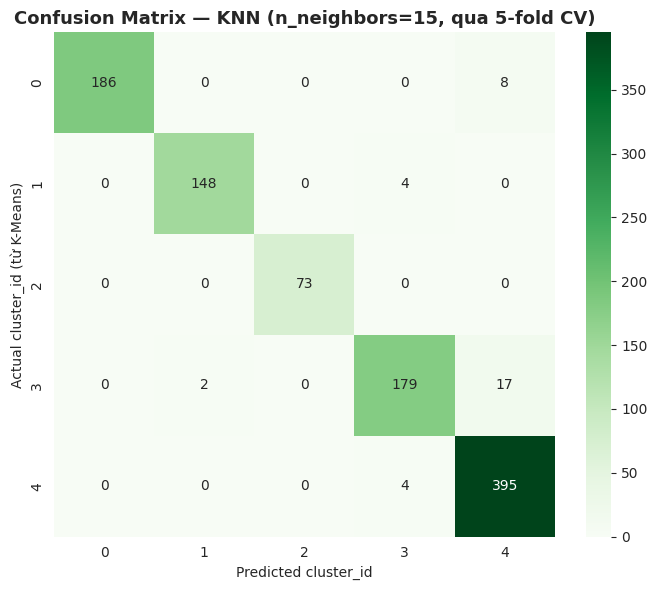

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       194
           1       0.99      0.97      0.98       152
           2       1.00      1.00      1.00        73
           3       0.96      0.90      0.93       198
           4       0.94      0.99      0.96       399

    accuracy                           0.97      1016
   macro avg       0.98      0.97      0.97      1016
weighted avg       0.97      0.97      0.97      1016



In [111]:
BEST_N_NEIGHBORS = knn_results_df["cv_accuracy_mean"].idxmax()
print("n_neighbors tốt nhất:", BEST_N_NEIGHBORS)

knn_final = KNeighborsClassifier(n_neighbors=BEST_N_NEIGHBORS)
y_pred = cross_val_predict(knn_final, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", ax=ax)
ax.set_xlabel("Predicted cluster_id")
ax.set_ylabel("Actual cluster_id (từ K-Means)")
ax.set_title(f"Confusion Matrix — KNN (n_neighbors={BEST_N_NEIGHBORS}, qua 5-fold CV)")
plt.tight_layout()
plt.show()

print(classification_report(y, y_pred))


**Đọc confusion matrix:** cụm Thủ môn (cluster 2) đạt **precision/recall = 100%** — hoàn toàn tách biệt, dễ hiểu vì thủ môn có profile khác hẳn cầu thủ ngoài sân. Nhầm lẫn chủ yếu xảy ra giữa 2 cụm "mixed" (đã phân tích ở mục 6.2) và cụm tiền vệ trung tâm/hậu vệ biên (cluster 4) — hợp lý vì đây vốn là các nhóm có ranh giới mờ trong thực tế bóng đá (không phải lỗi mô hình).

## Kết luận tổng hợp Task 6

1. **Cụm K-Means có ý nghĩa thực tế rõ ràng**: 3/5 cụm khớp gần như hoàn hảo với nhóm vị trí truyền thống (Thủ môn 100%, Hậu vệ ~97%, Tiền đạo ~95% purity); overall NMI ≈0.51-0.55.
2. **2 cụm còn lại tiết lộ phong cách chơi cắt ngang vị trí chính thức** — "tấn công sáng tạo biên" (winger + AM) và "triển khai bóng tuyến sâu" (fullback + tiền vệ phòng ngự) — đúng giá trị mà Style Clustering mang lại so với chỉ dùng nhãn vị trí có sẵn.
3. **Cấu trúc cụm ổn định về mặt hình học**: KNN đạt ~96.6% CV accuracy khi dự đoán `cluster_id` từ feature — xác nhận 5 cụm là vùng tách biệt thật trong không gian 29 chiều, không phải nhiễu ngẫu nhiên từ 1 lần chạy K-Means.

Đây khép lại toàn bộ pipeline: Task 1 (trích xuất) → Task 2/3 (EDA) → Task 4 (Preprocessing) → Task 5 (K-Means + so sánh scaler) → Task 6 (Validate + KNN + CV) cho bài toán Player Style Clustering.


---
## 6.6 — Trực quan hóa cụm bằng hình ảnh

Gắn tên cụm đã đặt ở mục 6.3 vào biểu đồ PCA 2D (cùng phương pháp đã dùng ở Task 5) để xem 5 phong cách tách biệt ra sao trong không gian 29 chiều. Dùng chung bảng màu/marker với Task 5 để 2 notebook nhất quán khi đối chiếu.

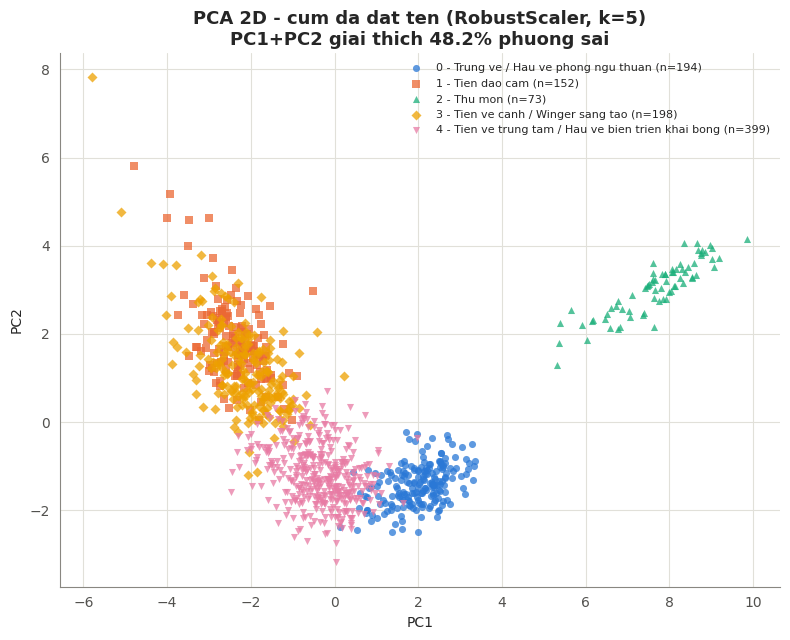

In [112]:
from sklearn.decomposition import PCA

CLUSTER_NAMES = {
    0: "Trung ve / Hau ve phong ngu thuan",
    1: "Tien dao cam",
    2: "Thu mon",
    3: "Tien ve canh / Winger sang tao",
    4: "Tien ve trung tam / Hau ve bien trien khai bong",
}

# Cung bang mau + marker voi Task 5 (thu tu cluster khong doi giua 2 notebook)
CLUSTER_COLORS = {0: "#2a78d6", 1: "#eb6834", 2: "#1baf7a", 3: "#eda100", 4: "#e87ba4"}
CLUSTER_MARKERS = {0: "o", 1: "s", 2: "^", 3: "D", 4: "v"}

GRID_COLOR = "#e1e0d9"
MUTED_INK = "#898781"
SECONDARY_INK = "#52514e"


def _style_axes(ax):
    ax.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    for spine in ("left", "bottom"):
        ax.spines[spine].set_color(MUTED_INK)
    ax.tick_params(colors=SECONDARY_INK)


assert (X_robust_df["player_id"].values == clusters_df["player_id"].values).all(), (
    "Thu tu hang khong khop giua player_X_robust_scaled.csv va player_clusters_k5.csv - can merge theo player_id"
)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_robust_df[FEATURE_COLS].values)
evr = pca.explained_variance_ratio_

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["cluster_id"] = clusters_df["cluster_id"].values

fig, ax = plt.subplots(figsize=(8, 6.5))
for c in sorted(CLUSTER_NAMES):
    sub = pca_df[pca_df["cluster_id"] == c]
    ax.scatter(
        sub["PC1"], sub["PC2"],
        s=26, alpha=0.75, linewidths=0,
        color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
        label=f"{c} - {CLUSTER_NAMES[c]} (n={len(sub)})",
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"PCA 2D - cum da dat ten (RobustScaler, k=5)\nPC1+PC2 giai thich {evr.sum():.1%} phuong sai")
_style_axes(ax)
ax.legend(frameon=False, fontsize=8, loc="best")
plt.tight_layout()
plt.show()


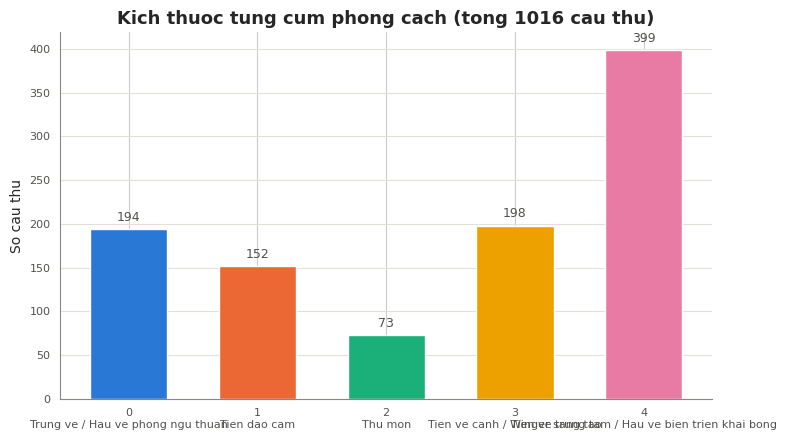

In [113]:
cluster_sizes = clusters_df["cluster_id"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
labels_with_name = [f"{c}\n{CLUSTER_NAMES[c]}" for c in cluster_sizes.index]
bars = ax.bar(
    labels_with_name, cluster_sizes.values,
    color=[CLUSTER_COLORS[c] for c in cluster_sizes.index], width=0.6,
)
for rect, val in zip(bars, cluster_sizes.values):
    ax.text(
        rect.get_x() + rect.get_width() / 2, rect.get_height() + 6, str(val),
        ha="center", va="bottom", fontsize=9, color=SECONDARY_INK,
    )

ax.set_ylabel("So cau thu")
ax.set_title(f"Kich thuoc tung cum phong cach (tong {cluster_sizes.sum()} cau thu)")
ax.grid(True, axis="y", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color(MUTED_INK)
ax.tick_params(colors=SECONDARY_INK, labelsize=8)
plt.tight_layout()
plt.show()


---
## 6.7 — Barcelona vs Real Madrid: cầu thủ nào rơi vào cụm nào

Lọc cầu thủ có `primary_team` chứa "Barcelona" hoặc "Real Madrid", đối chiếu `cluster_id` (đã đặt tên ở 6.3), rồi vẽ **vị trí trung bình trên sân** của từng cầu thủ (`avg_location_x`, `avg_location_y` — feature có sẵn từ Task 4, không cần tính lại) lên sơ đồ sân bóng chuẩn StatsBomb (120×80), tô màu theo cụm phong cách. Đây là cách trực quan nhất để đối chiếu K-Means với hiểu biết thực tế về đội hình 2 CLB.

In [114]:
from matplotlib.patches import Circle


def draw_full_pitch(ax, line_color="#898781"):
    ax.plot([0, 0, 120, 120, 0], [0, 80, 80, 0, 0], color=line_color, linewidth=1.2)
    ax.plot([60, 60], [0, 80], color=line_color, linewidth=1.2)
    ax.add_patch(Circle((60, 40), 9.15, fill=False, color=line_color, linewidth=1.2))
    ax.add_patch(Circle((60, 40), 0.4, color=line_color))
    # Vong cam + vong 5m50 - ben trai
    ax.plot([0, 18, 18, 0], [18, 18, 62, 62], color=line_color, linewidth=1.2)
    ax.plot([0, 6, 6, 0], [30, 30, 50, 50], color=line_color, linewidth=1.2)
    # Vong cam + vong 5m50 - ben phai
    ax.plot([120, 102, 102, 120], [18, 18, 62, 62], color=line_color, linewidth=1.2)
    ax.plot([120, 114, 114, 120], [30, 30, 50, 50], color=line_color, linewidth=1.2)
    ax.set_xlim(-3, 123)
    ax.set_ylim(-3, 83)
    ax.set_aspect("equal")
    ax.axis("off")


TEAMS_OF_INTEREST = ["Barcelona", "Real Madrid"]

team_profile_df = clusters_df.merge(
    X_unscaled_df[["player_id", "avg_location_x", "avg_location_y"]], on="player_id"
)
team_mask = team_profile_df["primary_team"].str.contains(
    "|".join(TEAMS_OF_INTEREST), case=False, na=False
)
team_players = team_profile_df[team_mask].copy()
team_players["cluster_name"] = team_players["cluster_id"].map(CLUSTER_NAMES)

print("So cau thu tim thay theo primary_team (chua tach theo tung doi trong TEAMS_OF_INTEREST):")
print(team_players["primary_team"].value_counts())


So cau thu tim thay theo primary_team (chua tach theo tung doi trong TEAMS_OF_INTEREST):
primary_team
Real Madrid    18
Barcelona      13
Name: count, dtype: int64


In [115]:
from IPython.display import display

for team in TEAMS_OF_INTEREST:
    sub = (
        team_players[team_players["primary_team"].str.contains(team, case=False, na=False)]
        .sort_values(["cluster_id", "player_name"])
    )
    print(f"\n=== {team} (n={len(sub)} cau thu) ===")
    display(sub[["player_name", "cluster_id", "cluster_name", "avg_location_x", "avg_location_y"]].reset_index(drop=True))



=== Barcelona (n=13 cau thu) ===


,player_name,cluster_id,cluster_name,avg_location_x,avg_location_y
0,Gerard Piqué Bernabéu,0,Trung ve / Hau ve phong ngu thuan,43.484,55.045
1,Javier Alejandro Mascherano,0,Trung ve / Hau ve phong ngu thuan,45.417,34.535
2,Jérémy Mathieu,0,Trung ve / Hau ve phong ngu thuan,46.575,21.866
3,Luis Alberto Suárez Díaz,1,Tien dao cam,87.325,41.879
4,Claudio Andrés Bravo Muñoz,2,Thu mon,10.476,39.857
5,Andrés Iniesta Luján,3,Tien ve canh / Winger sang tao,69.393,26.704
6,Daniel Alves da Silva,3,Tien ve canh / Winger sang tao,66.034,68.087
7,Ivan Rakitić,3,Tien ve canh / Winger sang tao,67.733,54.995
8,Lionel Andrés Messi Cuccittini,3,Tien ve canh / Winger sang tao,80.034,52.080
9,Neymar da Silva Santos Junior,3,Tien ve canh / Winger sang tao,83.333,20.294



=== Real Madrid (n=18 cau thu) ===


,player_name,cluster_id,cluster_name,avg_location_x,avg_location_y
0,José Ignacio Fernández Iglesias,0,Trung ve / Hau ve phong ngu thuan,46.491,25.395
1,Kléper Laveran Lima Ferreira,0,Trung ve / Hau ve phong ngu thuan,44.415,54.922
2,Raphaël Varane,0,Trung ve / Hau ve phong ngu thuan,40.490,42.664
3,Sergio Ramos García,0,Trung ve / Hau ve phong ngu thuan,44.595,25.017
4,Cristiano Ronaldo dos Santos Aveiro,1,Tien dao cam,84.171,31.178
5,Gareth Frank Bale,1,Tien dao cam,79.551,47.397
6,Karim Benzema,1,Tien dao cam,83.138,36.214
7,Keylor Navas Gamboa,2,Thu mon,8.854,40.547
8,Francisco Román Alarcón Suárez,3,Tien ve canh / Winger sang tao,72.494,35.497
9,James David Rodríguez Rubio,3,Tien ve canh / Winger sang tao,73.230,40.046


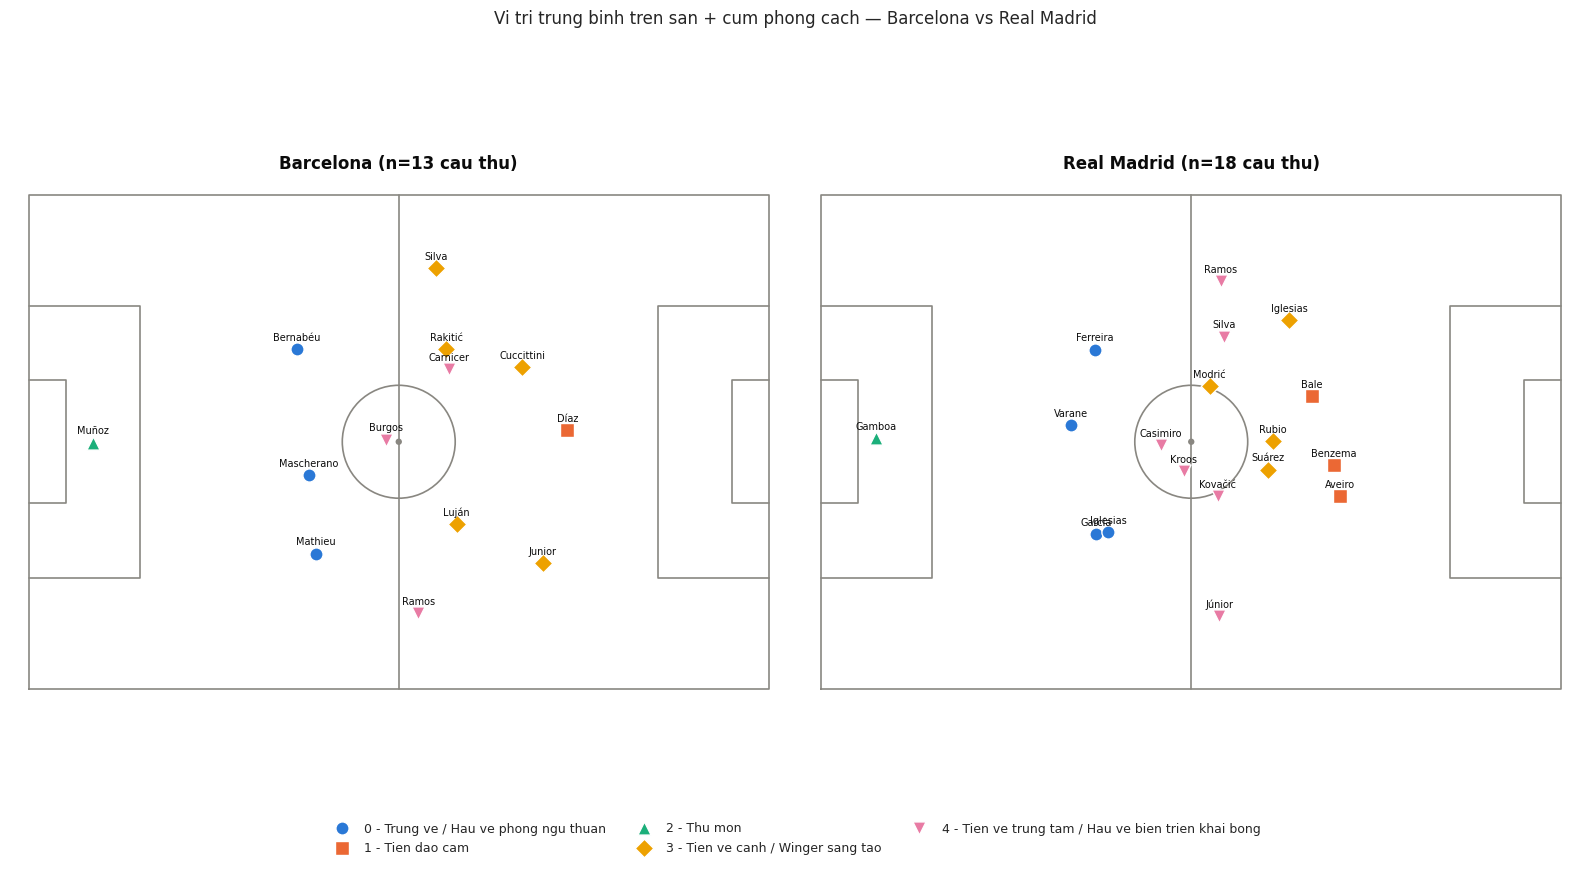

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, team in zip(axes, TEAMS_OF_INTEREST):
    draw_full_pitch(ax)
    sub = team_players[team_players["primary_team"].str.contains(team, case=False, na=False)]

    for c in sorted(CLUSTER_NAMES):
        sub_c = sub[sub["cluster_id"] == c]
        if sub_c.empty:
            continue
        ax.scatter(
            sub_c["avg_location_x"], sub_c["avg_location_y"],
            s=90, color=CLUSTER_COLORS[c], marker=CLUSTER_MARKERS[c],
            edgecolors="white", linewidths=1, zorder=3,
            label=f"{c} - {CLUSTER_NAMES[c]}",
        )

    for _, row in sub.iterrows():
        short_name = row["player_name"].split()[-1]
        ax.annotate(
            short_name, (row["avg_location_x"], row["avg_location_y"]),
            fontsize=7, color="#0b0b0b", ha="center", va="bottom",
            xytext=(0, 5), textcoords="offset points",
        )

    ax.set_title(f"{team} (n={len(sub)} cau thu)", fontsize=12, color="#0b0b0b")

# Gop legend tu ca 2 subplot, khong trung lap
handles_all, labels_all = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    for hh, ll in zip(h, l):
        if ll not in labels_all:
            handles_all.append(hh)
            labels_all.append(ll)

fig.legend(handles_all, labels_all, loc="lower center", ncol=3, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Vi tri trung binh tren san + cum phong cach — Barcelona vs Real Madrid", y=1.02)
plt.tight_layout()
plt.show()


**Cách đọc & lưu ý:**
- Vị trí mỗi chấm là **trung bình vị trí cả giai đoạn dữ liệu** (`avg_location_x/y`), không phải đội hình 1 trận cụ thể — cầu thủ dự bị/đá nhiều vai trò trong tập dữ liệu có thể lệch khỏi vị trí "quen thuộc".
- Nếu 1 CLB thiếu hẳn 1 cụm nào đó trên sân (không có chấm màu tương ứng) — nghĩa là CLB đó không có cầu thủ nào rơi vào phong cách đó trong tập dữ liệu đang dùng (khác với "CLB không có vị trí đó").
- Nên đối chiếu bảng ở cell trước (tên cầu thủ + `cluster_name` cụ thể) khi cần biết chính xác 1 cầu thủ rơi vào cụm nào, thay vì chỉ đọc trên sơ đồ sân.

Đây là phần mở rộng minh hoạ (Task 6 phụ lục) — không thay đổi kết luận chính thức của Task 6 đã chốt ở mục trước.